## Task 1:Line plot

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

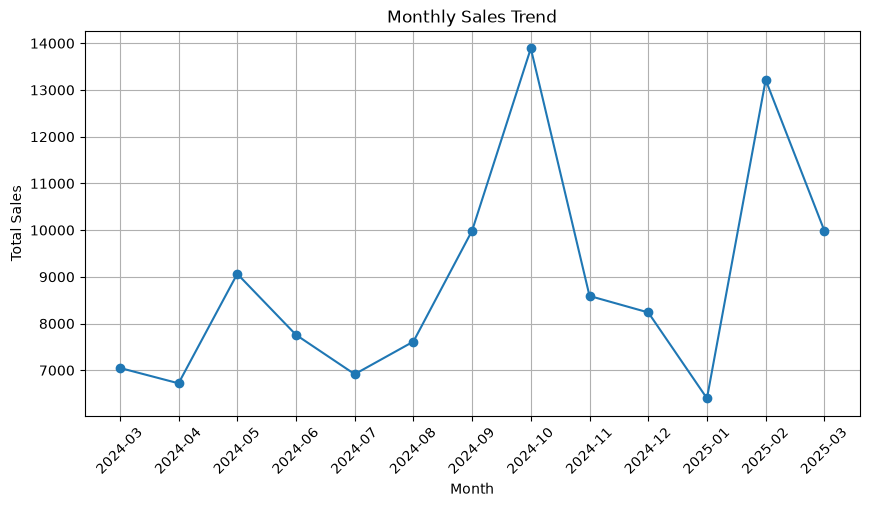

In [6]:
sales['date'] = pd.to_datetime(sales['date'])

monthly_sales = sales.groupby(
    sales['date'].dt.to_period('M')
)['money'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Task 2:Scatter plot()

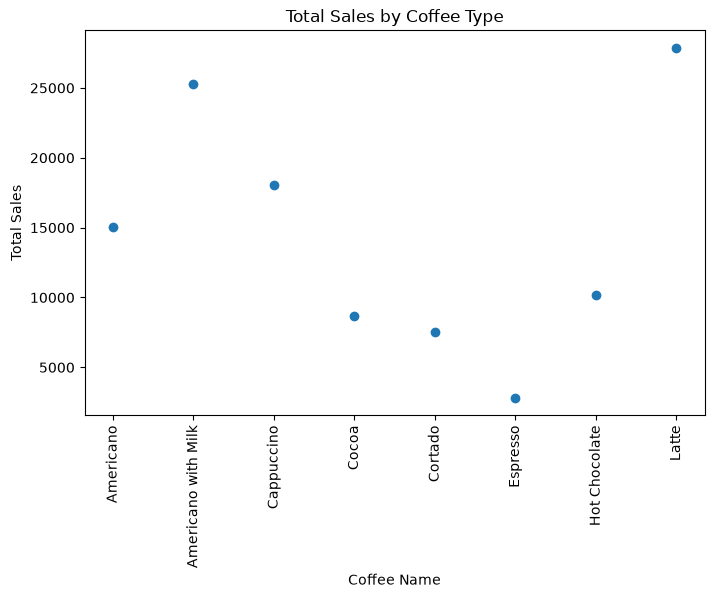

In [7]:
coffee_sales = sales.groupby('coffee_name')['money'].sum()

plt.figure(figsize=(8,5))

plt.scatter(
    coffee_sales.index,
    coffee_sales.values
)

plt.title('Total Sales by Coffee Type')
plt.xlabel('Coffee Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)

plt.show()

## Task 3:bar plot()

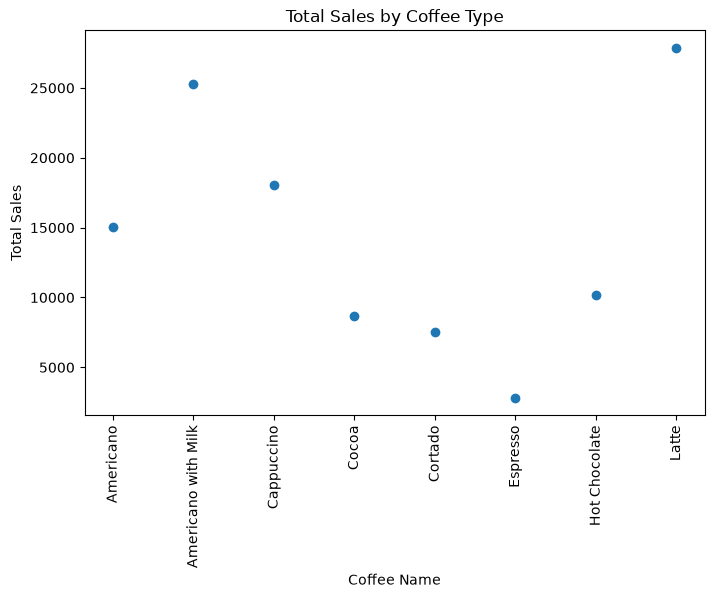

In [8]:
coffee_sales = sales.groupby('coffee_name')['money'].sum()

plt.figure(figsize=(8,5))

plt.scatter(
    coffee_sales.index,
    coffee_sales.values
)

plt.title('Total Sales by Coffee Type')
plt.xlabel('Coffee Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)

plt.show()

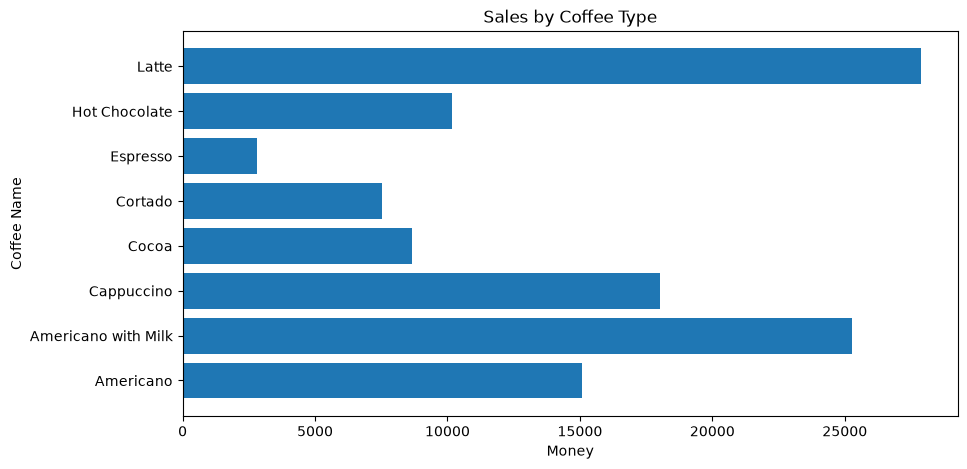

In [9]:
plt.figure(figsize=(10,5))

plt.barh(
    coffee_sales.index,
    coffee_sales.values
)

plt.title('Sales by Coffee Type')
plt.xlabel('Money')
plt.ylabel('Coffee Name')

plt.show()

## Task 4: Multiple Bar plot()

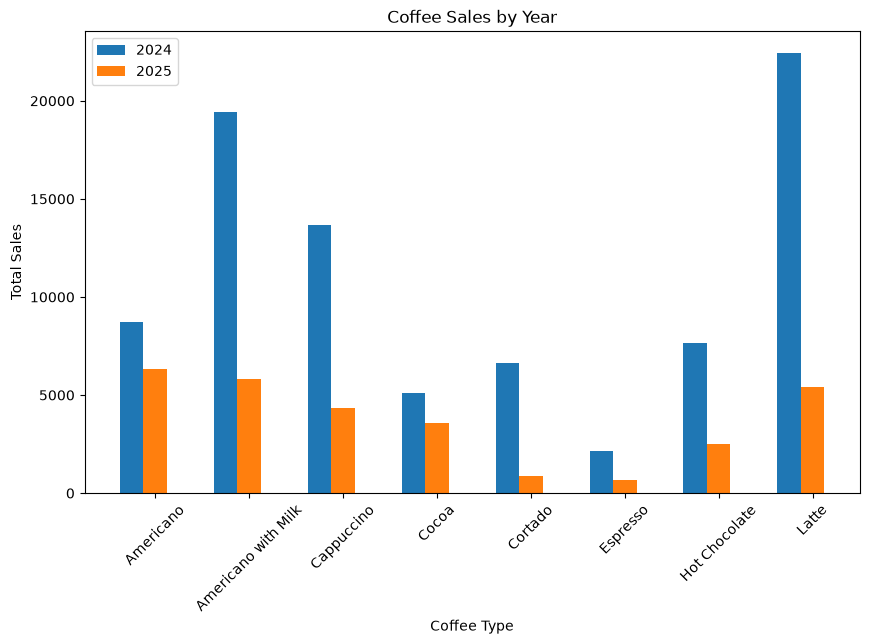

In [10]:
sales['year'] = sales['date'].dt.year

yearly_sales = sales.pivot_table(
    index='coffee_name',
    columns='year',
    values='money',
    aggfunc='sum',
    fill_value=0
)

years = yearly_sales.columns
x = range(len(yearly_sales.index))

bar_width = 0.25

plt.figure(figsize=(10,6))

for i, year in enumerate(years):
    plt.bar(
        [p + i*bar_width for p in x],
        yearly_sales[year],
        width=bar_width,
        label=str(year)
    )

plt.title('Coffee Sales by Year')
plt.xlabel('Coffee Type')
plt.ylabel('Total Sales')
plt.xticks(
    [p + bar_width for p in x],
    yearly_sales.index,
    rotation=45
)
plt.legend()

plt.show()

## Task 5:Stacked bar chart()

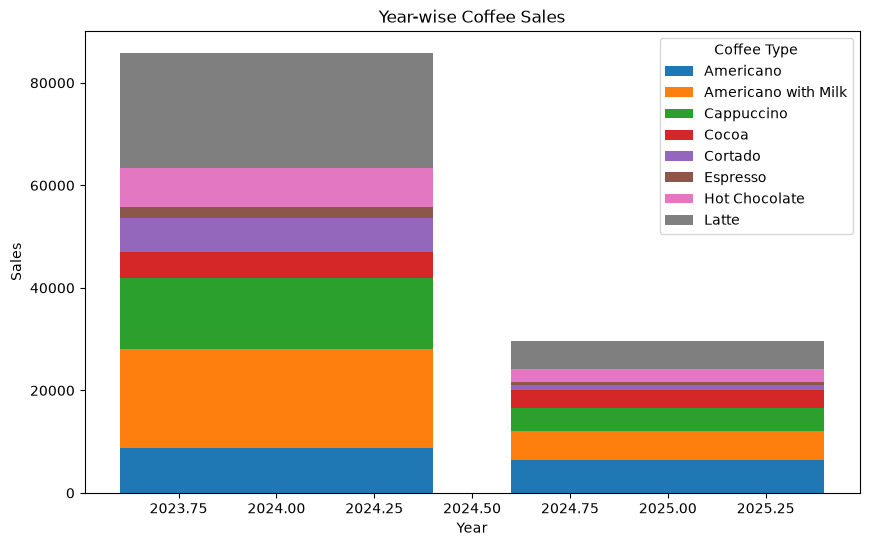

In [13]:
stacked_data = sales.pivot_table(
    index='year',
    columns='coffee_name',
    values='money',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(10,6))

bottom = [0] * len(stacked_data)

for coffee in stacked_data.columns:
    plt.bar(
        stacked_data.index,
        stacked_data[coffee],
        bottom=bottom,
        label=coffee
    )

    bottom = [
        bottom[i] + stacked_data[coffee].iloc[i]
        for i in range(len(bottom))
    ]

plt.title('Year-wise Coffee Sales')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend(title='Coffee Type')

plt.show()

## Task 6 : Histogram 

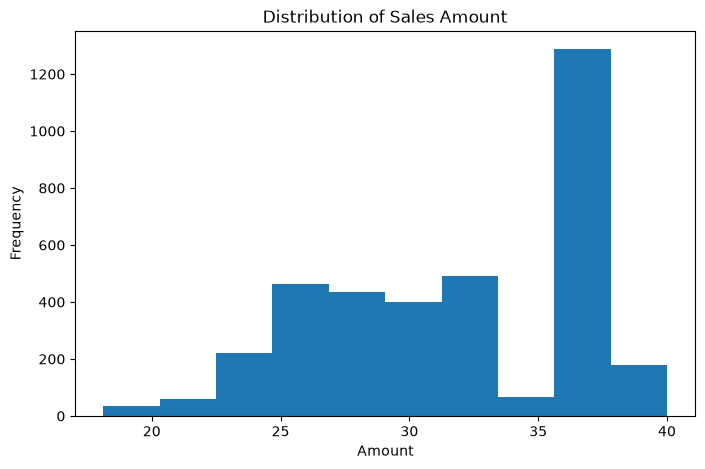

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    sales['money'],
    bins=10
)

plt.title('Distribution of Sales Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

## Task 7:Pie chart

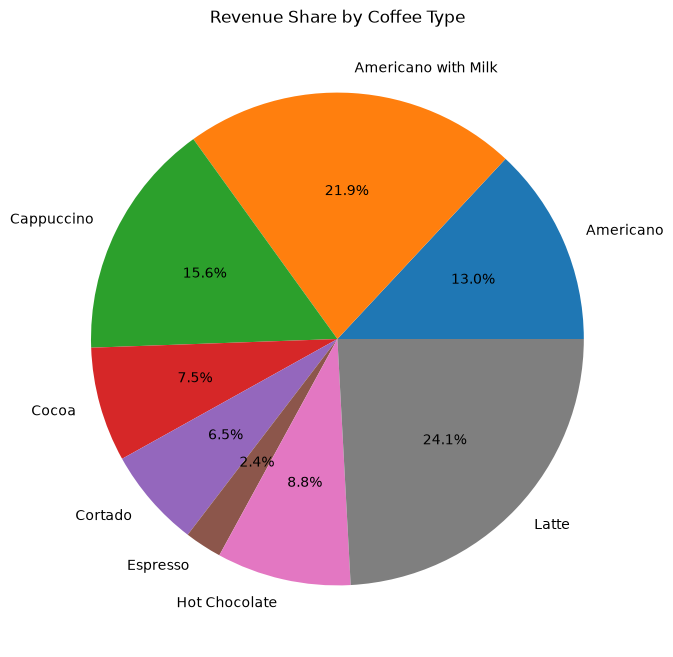

In [15]:
coffee_sales = sales.groupby('coffee_name')['money'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    coffee_sales.values,
    labels=coffee_sales.index,
    autopct='%1.1f%%'
)

plt.title('Revenue Share by Coffee Type')

plt.show()